<a href="https://colab.research.google.com/github/newts0fa/ml-basics/blob/main/%E2%84%9612.2%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D0%93%D0%B5%D0%BE%D0%BC%D0%B0%D1%80%D0%BA%D0%B5%D1%82%D0%B8%D0%BD%D0%B3%D0%BE%D0%B2%D0%BE%D0%B5_%D0%B8%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D1%82%D0%B5%D1%80%D1%80%D0%B8%D1%82%D0%BE%D1%80%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геомаркетинговое исследование территорий с применением методов машинного обучения**


## **Цель работы**


Овладеть методами пространственного анализа и машинного обучения для решения практической задачи определения оптимальных локаций размещения коммерческих объектов.

## **Введение**


В современном бизнесе местоположение коммерческого объекта играет ключевую роль в его успешности. Геомаркетинговый анализ позволяет объективно оценить привлекательность различных локаций, опираясь на количественные показатели и алгоритмы машинного обучения.

В рамках данной работы вы примените полный цикл пространственного анализа, включая сбор данных из открытых источников, обработку и агрегацию пространственной информации, обучение моделей машинного обучения и визуализацию результатов.

## **Задание**


Провести геомаркетинговое исследование для выбора оптимальных локаций размещения новых точек определенного типа бизнеса на территории выбранного города.

## **Порядок выполнения работы**

### **Часть 1. Подготовка данных и определение задачи**



1. **Индивидуальный выбор территории и типа бизнеса**:
   - Выберите город/район для проведения анализа (например, центральная часть Москвы, Санкт-Петербурга или любого другого крупного города)
   - Определите тип бизнеса для анализа (аптеки, продуктовые магазины, пункты выдачи заказов, рестораны определенной кухни и т.д.)
   - Обоснуйте свой выбор: почему данная территория и тип бизнеса интересны для анализа?

2. **Определение ключевых факторов успешности**:
   - Самостоятельно сформулируйте не менее 5 факторов, которые могут влиять на успешность выбранного типа бизнеса
   - Для каждого фактора определите, какими данными из OpenStreetMap его можно количественно описать
   - Составьте таблицу соответствия между факторами и тегами OpenStreetMap

3. **Сбор исходных данных**:
   - Настройте необходимые библиотеки из теоретического материала
   - Определите необходимую область интереса (ROI) с помощью интерактивной карты
   - Загрузите данные о существующих объектах вашего типа бизнеса и объектах инфраструктуры, связанных с выделенными вами факторами

In [11]:


import sys
import subprocess
import importlib.util

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "geopandas": "geopandas",
    "shapely": "shapely",
    "folium": "folium",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "h3": "h3",
    "osmnx": "osmnx",
}

missing_packages = [pip_name for import_name, pip_name in required_packages.items() if importlib.util.find_spec(import_name) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import h3
import osmnx as ox
import matplotlib.pyplot as plt
import seaborn as sns

from shapely.geometry import Point, Polygon, box
from IPython.display import display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

city_name = "Центральная Москва"
business_type = "аптека"
roi_polygon = box(37.57, 55.735, 37.67, 55.785)
roi_gdf = gpd.GeoDataFrame({"name": [city_name]}, geometry=[roi_polygon], crs="EPSG:4326")

factor_table = pd.DataFrame([
    ["Существующая конкуренция", "amenity=pharmacy", "Количество аптек и расстояние до них"],
    ["Транспортный поток", "highway=bus_stop; railway=station", "Остановки и станции рядом"],
    ["Повседневный спрос", "shop=*; amenity=cafe/restaurant", "Магазины и кафе рядом"],
    ["Комплементарные сервисы", "amenity=bank/atm/clinic/doctors", "Сервисы, усиливающие поток"],
    ["Учебная активность", "amenity=school/university/college", "Места со стабильным дневным населением"],
], columns=["Фактор", "Теги OSM", "Описание"])

display(pd.DataFrame({
    "Территория": [city_name],
    "Тип бизнеса": [business_type],
    "Обоснование": ["Центральная территория имеет высокий пешеходный поток, много сервисов и заметную конкуренцию."],
}))
display(factor_table)

def ox_features_from_polygon(polygon, tags):
    if hasattr(ox, "features_from_polygon"):
        return ox.features_from_polygon(polygon, tags)
    return ox.geometries_from_polygon(polygon, tags)

def to_points(gdf, layer_name):
    if gdf is None or len(gdf) == 0:
        return gpd.GeoDataFrame({"layer": []}, geometry=[], crs="EPSG:4326")
    points = gdf.copy()
    points = points[points.geometry.notna()].copy()
    points["geometry"] = points.geometry.representative_point()
    points = points.set_crs("EPSG:4326", allow_override=True)
    points = points[points.within(roi_polygon)].copy()
    points["layer"] = layer_name
    return points[["layer", "geometry"]]

def random_points_in_polygon(polygon, n, layer_name):
    minx, miny, maxx, maxy = polygon.bounds
    pts = []
    while len(pts) < n:
        p = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
        if polygon.contains(p):
            pts.append(p)
    return gpd.GeoDataFrame({"layer": [layer_name] * n}, geometry=pts, crs="EPSG:4326")

osm_tags = {
    "pharmacies": {"amenity": "pharmacy"},
    "transit": {"highway": "bus_stop", "railway": "station", "public_transport": "platform"},
    "food": {"amenity": ["cafe", "restaurant", "fast_food"]},
    "retail": {"shop": True},
    "finance_health": {"amenity": ["bank", "atm", "clinic", "doctors", "dentist"]},
    "education": {"amenity": ["school", "university", "college", "kindergarten"]},
}

layers = {}
try:
    for layer_name, tags in osm_tags.items():
        layers[layer_name] = to_points(ox_features_from_polygon(roi_polygon, tags), layer_name)
except Exception as exc:
    print("Загрузка OSM не удалась. Будут использованы тестовые точки.")
    print(type(exc).__name__, str(exc)[:300])
    demo_sizes = {"pharmacies": 35, "transit": 120, "food": 150, "retail": 180, "finance_health": 90, "education": 45}
    layers = {name: random_points_in_polygon(roi_polygon, n, name) for name, n in demo_sizes.items()}

for name, layer in layers.items():
    print(f"{name}: {len(layer)} объектов")

m_initial = folium.Map(location=[55.76, 37.62], zoom_start=13, tiles="CartoDB positron")
folium.GeoJson(roi_gdf, name="Область исследования", style_function=lambda x: {"color": "black", "weight": 2, "fillOpacity": 0}).add_to(m_initial)
layer_colors = {"pharmacies": "green", "transit": "blue", "food": "orange", "retail": "green", "finance_health": "purple", "education": "cadetblue"}
for layer_name, gdf in layers.items():
    fg = folium.FeatureGroup(name=layer_name, show=(layer_name == "pharmacies"))
    for geom in gdf.geometry.head(300):
        folium.CircleMarker(location=[geom.y, geom.x], radius=3 if layer_name == "pharmacies" else 2, color=layer_colors.get(layer_name, "gray"), fill=True, fill_opacity=0.75, popup=layer_name).add_to(fg)
    fg.add_to(m_initial)
folium.LayerControl().add_to(m_initial)
m_initial


,Территория,Тип бизнеса,Обоснование
0,Центральная Москва,аптека,Центральная территория имеет высокий пешеходны...


,Фактор,Теги OSM,Описание
0,Существующая конкуренция,amenity=pharmacy,Количество аптек и расстояние до них
1,Транспортный поток,highway=bus_stop; railway=station,Остановки и станции рядом
2,Повседневный спрос,shop=*; amenity=cafe/restaurant,Магазины и кафе рядом
3,Комплементарные сервисы,amenity=bank/atm/clinic/doctors,"Сервисы, усиливающие поток"
4,Учебная активность,amenity=school/university/college,Места со стабильным дневным населением


pharmacies: 325 объектов
transit: 757 объектов
food: 2928 объектов
retail: 6289 объектов
finance_health: 1533 объектов
education: 318 объектов


### **Часть 2. Пространственное агрегирование и создание признаков**


1. **Создание гексагональной сетки**:
   - Самостоятельно определите оптимальную детализацию сетки H3 для вашего анализа
   - Обоснуйте выбор разрешения (resolution) сетки с учётом масштаба вашей территории и специфики бизнеса
   - Покройте территорию гексагональной сеткой выбранного разрешения

2. **Инженерия пространственных признаков**:
   - Определите радиусы для анализа ближнего и среднего окружения (могут отличаться от предложенных в теории в зависимости от специфики вашего бизнеса)
   - Разработайте и реализуйте не менее 10 пространственных признаков, описывающих характеристики каждой ячейки
   - **Дополнительное задание**: придумайте и реализуйте не менее 2 пространственных признаков, которых нет в теоретическом материале

3. **Анализ полученных признаков**:
   - Рассчитайте базовую статистику по каждому признаку
   - Исследуйте корреляции между признаками
   - Выявите и обработайте выбросы и пропущенные значения, если они имеются

Разрешение H3: 8
Обоснование: resolution 8 дает ячейки квартального масштаба.
Количество ячеек сетки: 61


,count,mean,std,min,25%,50%,75%,max,Пропуски
pharmacy_count_300m,61.0,0.744262,1.286925,0.000000,0.000000,0.000000,1.000000,5.400000,0
pharmacy_count_600m,61.0,2.727869,2.444867,0.000000,1.000000,2.000000,4.000000,8.400000,0
nearest_pharmacy_m,61.0,424.043292,266.080264,49.825496,216.512256,378.684272,538.529165,1132.978406,0
transit_count_300m,61.0,1.832787,2.639237,0.000000,0.000000,1.000000,2.000000,12.800000,0
transit_count_600m,61.0,6.239344,4.851229,0.000000,2.000000,6.000000,8.000000,22.600000,0
food_count_300m,61.0,7.226230,9.533553,0.000000,1.000000,4.000000,10.000000,45.800000,0
retail_count_300m,61.0,12.950820,13.880954,0.000000,2.000000,10.000000,19.000000,60.000000,0
finance_health_count_400m,61.0,6.042623,6.009228,0.000000,1.000000,4.000000,9.000000,23.600000,0
education_count_600m,61.0,2.606557,1.800728,0.000000,1.000000,3.000000,4.000000,6.000000,0
poi_diversity_500m,61.0,4.344262,1.123762,0.000000,4.000000,5.000000,5.000000,5.000000,0


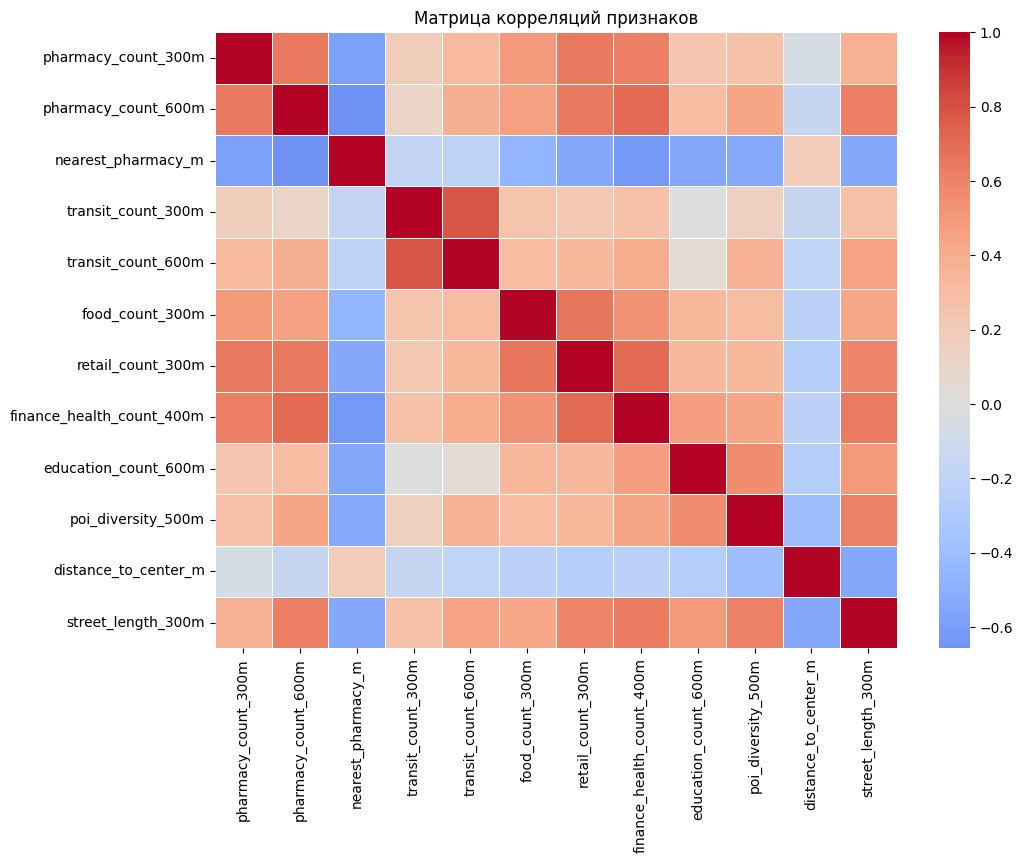

,h3_cell,geometry,cell_id,pharmacy_in_cell,pharmacy_count_300m,pharmacy_count_600m,nearest_pharmacy_m,transit_count_300m,transit_count_600m,food_count_300m,retail_count_300m,finance_health_count_400m,education_count_600m,poi_diversity_500m,distance_to_center_m,street_length_300m
0,8811aa7ad1fffff,"POLYGON ((37.57421 55.78311, 37.57863 55.77919...",0,4,0.0,3.0,327.674561,0.0,2.0,4.0,3,4.0,2,4,7392.764818,4050.312562
1,8811aa7aa7fffff,"POLYGON ((37.61486 55.73947, 37.61927 55.73554...",1,5,0.0,1.0,379.192394,1.0,8.0,10.0,13,4.0,4,5,2454.147545,11745.615608
2,8811aa7ab7fffff,"POLYGON ((37.63675 55.7575, 37.64116 55.75358,...",2,8,2.0,5.0,210.190351,1.0,8.0,21.0,20,4.0,3,5,3235.727026,18502.676543
3,8811aa78c9fffff,"POLYGON ((37.62626 55.74433, 37.63067 55.7404,...",3,3,0.0,1.0,434.657524,5.0,8.0,2.0,8,9.0,4,5,2330.816512,19590.708325
4,8811aa78c3fffff,"POLYGON ((37.64998 55.74572, 37.65439 55.74179...",4,5,1.0,4.0,239.897470,1.0,7.0,6.0,19,16.0,3,5,4630.337361,18756.729033


In [ ]:


h3_resolution = 8
print("Разрешение H3:", h3_resolution)
print("Обоснование: resolution 8 дает ячейки квартального масштаба.")

def h3_to_cell(lat, lon, resolution):
    if hasattr(h3, "latlng_to_cell"):
        return h3.latlng_to_cell(lat, lon, resolution)
    return h3.geo_to_h3(lat, lon, resolution)

def h3_boundary(cell_id):
    if hasattr(h3, "cell_to_boundary"):
        boundary = h3.cell_to_boundary(cell_id)
    else:
        boundary = h3.h3_to_geo_boundary(cell_id)
    return Polygon([(lng, lat) for lat, lng in boundary])

def build_h3_grid(polygon, resolution, step_deg=0.0018):
    minx, miny, maxx, maxy = polygon.bounds
    cells = set()
    for lon in np.arange(minx, maxx + step_deg, step_deg):
        for lat in np.arange(miny, maxy + step_deg, step_deg):
            if polygon.contains(Point(lon, lat)):
                cells.add(h3_to_cell(lat, lon, resolution))
    grid = gpd.GeoDataFrame({"h3_cell": list(cells)}, geometry=[h3_boundary(c) for c in cells], crs="EPSG:4326")
    grid = grid[grid.intersects(polygon)].copy().reset_index(drop=True)
    grid["cell_id"] = np.arange(len(grid))
    return grid

grid = build_h3_grid(roi_polygon, h3_resolution)
print("Количество ячеек сетки:", len(grid))

grid_m = grid.to_crs(epsg=3857)
grid_m["centroid"] = grid_m.geometry.centroid
centroids_m = gpd.GeoDataFrame(grid_m[["cell_id"]].copy(), geometry=grid_m["centroid"], crs="EPSG:3857")
layers_m = {name: gdf.to_crs(epsg=3857) for name, gdf in layers.items()}

def count_within(points_gdf, radius_m):
    if points_gdf is None or len(points_gdf) == 0:
        return np.zeros(len(centroids_m), dtype=int)
    point_geom = list(points_gdf.geometry)
    return np.array([sum(geom.distance(p) <= radius_m for p in point_geom) for geom in centroids_m.geometry])

def nearest_distance(points_gdf):
    if points_gdf is None or len(points_gdf) == 0:
        return np.full(len(centroids_m), np.nan)
    point_geom = list(points_gdf.geometry)
    return np.array([min(geom.distance(p) for p in point_geom) for geom in centroids_m.geometry])

def count_points_in_cell(points_gdf):
    if points_gdf is None or len(points_gdf) == 0:
        return np.zeros(len(grid), dtype=int)
    joined = gpd.sjoin(points_gdf.to_crs(grid.crs), grid[["cell_id", "geometry"]], predicate="within", how="left")
    counts = joined.groupby("cell_id").size()
    return grid["cell_id"].map(counts).fillna(0).astype(int).to_numpy()

features = grid.copy()
features["pharmacy_in_cell"] = count_points_in_cell(layers["pharmacies"])
features["pharmacy_count_300m"] = count_within(layers_m["pharmacies"], 300)
features["pharmacy_count_600m"] = count_within(layers_m["pharmacies"], 600)
features["nearest_pharmacy_m"] = nearest_distance(layers_m["pharmacies"])
features["transit_count_300m"] = count_within(layers_m["transit"], 300)
features["transit_count_600m"] = count_within(layers_m["transit"], 600)
features["food_count_300m"] = count_within(layers_m["food"], 300)
features["retail_count_300m"] = count_within(layers_m["retail"], 300)
features["finance_health_count_400m"] = count_within(layers_m["finance_health"], 400)
features["education_count_600m"] = count_within(layers_m["education"], 600)

counts_500 = {name: count_within(layers_m[name], 500) for name in ["transit", "food", "retail", "finance_health", "education"]}
features["poi_diversity_500m"] = [sum(counts_500[name][i] > 0 for name in counts_500) for i in range(len(features))]
kremlin = gpd.GeoSeries([Point(37.6176, 55.7520)], crs="EPSG:4326").to_crs(epsg=3857).iloc[0]
features["distance_to_center_m"] = centroids_m.geometry.distance(kremlin).to_numpy()

try:
    graph = ox.graph_from_polygon(roi_polygon, network_type="walk", simplify=True)
    _, edges = ox.graph_to_gdfs(graph)
    edges_m = edges.to_crs(epsg=3857)
    features["street_length_300m"] = [edges_m[edges_m.intersects(geom.buffer(300))].intersection(geom.buffer(300)).length.sum() for geom in centroids_m.geometry]
except Exception as exc:
    print("Уличная сеть не загрузилась, признак принят равным 0.")
    print(type(exc).__name__, str(exc)[:250])
    features["street_length_300m"] = 0.0

feature_cols = ["pharmacy_count_300m", "pharmacy_count_600m", "nearest_pharmacy_m", "transit_count_300m", "transit_count_600m", "food_count_300m", "retail_count_300m", "finance_health_count_400m", "education_count_600m", "poi_diversity_500m", "distance_to_center_m", "street_length_300m"]
features["nearest_pharmacy_m"] = features["nearest_pharmacy_m"].fillna(features["nearest_pharmacy_m"].max())
for col in feature_cols:
    lo, hi = features[col].quantile([0.01, 0.99])
    features[col] = features[col].clip(lo, hi)

stats = features[feature_cols].describe().T
missing = features[feature_cols].isna().sum().rename("Пропуски")
display(stats.join(missing))

corr = features[feature_cols].corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Матрица корреляций признаков")
plt.show()
features.head()


### **Часть 3. Моделирование привлекательности локаций**



1. **Подготовка целевой переменной**:
   - Определите, как будет сформирована целевая переменная для вашей задачи (по умолчанию: наличие объектов выбранного типа в ячейке)
   - Исследуйте распределение целевой переменной и оцените её сбалансированность
   - При необходимости, предложите стратегию работы с несбалансированными данными

2. **Разработка моделей машинного обучения**:
   - Реализуйте и обучите несколько моделей (минимум 2) для предсказания привлекательности локации
   - Проведите оценку важности признаков для каждой модели
   - Сравните модели по метрикам качества и выберите наилучшую
   - **Дополнительное задание**: настройте гиперпараметры модели с помощью поиска по сетке (GridSearchCV) или случайного поиска (RandomSearchCV)

3. **Улучшение модели с помощью кластеризации**:
   - Выполните кластеризацию ячеек по их характеристикам
   - Определите оптимальное число кластеров с помощью метода локтя или силуэта
   - Визуализируйте результаты кластеризации
   - Проверьте, улучшает ли добавление информации о кластерах качество основной модели

Распределение целевой переменной:


,target,cells
0,1,55
1,0,6


,model,accuracy,precision,recall,f1,roc_auc
1,Random forest,0.947368,0.944444,1.000000,0.971429,1.000000
0,Logistic regression,0.894737,1.000000,0.882353,0.937500,0.941176


Лучшие параметры Random Forest: {'max_depth': 3, 'min_samples_leaf': 2, 'n_estimators': 150}


,model,accuracy,precision,recall,f1,roc_auc
0,Random forest,0.947368,0.944444,1.000000,0.971429,1.000000
2,Tuned random forest,0.947368,0.944444,1.000000,0.971429,1.000000
1,Logistic regression,0.894737,1.000000,0.882353,0.937500,0.941176


Выбранная модель: Random forest


,feature,importance
2,nearest_pharmacy_m,0.356847
8,education_count_600m,0.192620
1,pharmacy_count_600m,0.168826
9,poi_diversity_500m,0.071822
10,distance_to_center_m,0.048501
7,finance_health_count_400m,0.040226
5,food_count_300m,0.035859
11,street_length_300m,0.028999
6,retail_count_300m,0.023384
4,transit_count_600m,0.018548


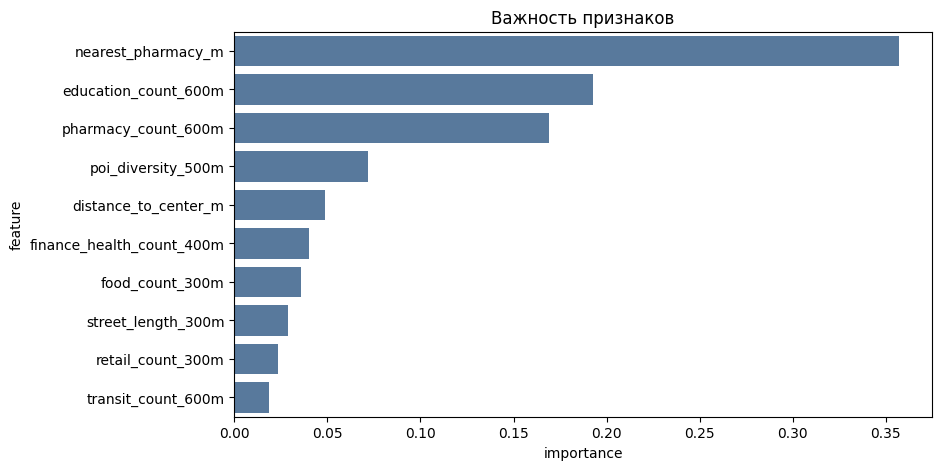

,k,silhouette
0,2,0.276592
1,3,0.203875
2,4,0.204395
3,5,0.202020
4,6,0.199998
5,7,0.215488
6,8,0.215976


Выбранное число кластеров: 2


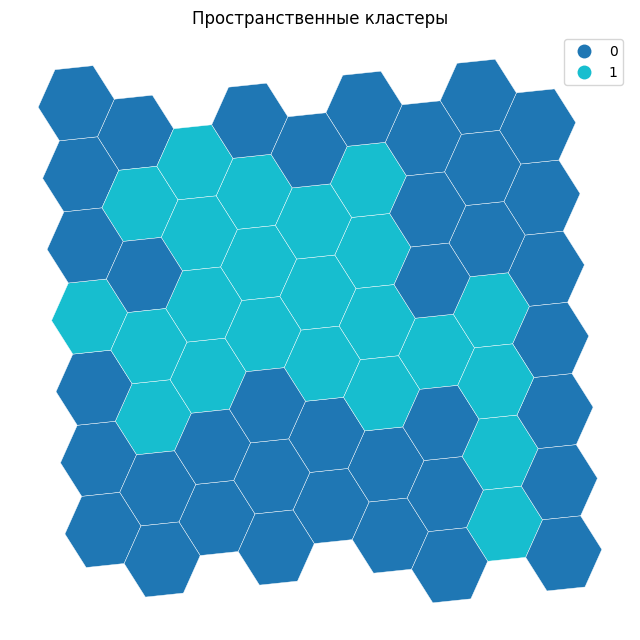

In [ ]:


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, silhouette_score
from sklearn.cluster import KMeans

model_df = features.copy()
model_df["target"] = (model_df["pharmacy_in_cell"] > 0).astype(int)
print("Распределение целевой переменной:")
display(model_df["target"].value_counts().rename_axis("target").reset_index(name="cells"))
X = model_df[feature_cols].copy()
y = model_df["target"].copy()
if y.nunique() < 2 or y.value_counts().min() < 2:
    print("Целевая переменная слишком разрежена, используется прокси-цель.")
    proxy_score = model_df["pharmacy_count_600m"] + model_df["transit_count_300m"] + model_df["retail_count_300m"] + model_df["food_count_300m"]
    y = (proxy_score >= proxy_score.quantile(0.65)).astype(int)
    if y.nunique() < 2:
        y = (pd.Series(np.arange(len(model_df)), index=model_df.index) % 2).astype(int)
    model_df["target"] = y
can_stratify = y.nunique() == 2 and y.value_counts().min() >= 2 and len(y) >= 10
split_args = dict(test_size=0.30, random_state=RANDOM_STATE)
if can_stratify:
    split_args["stratify"] = y
X_train, X_test, y_train, y_test = train_test_split(X, y, **split_args)
models = {
    "Logistic regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Random forest": RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2, class_weight="balanced", random_state=RANDOM_STATE),
}
results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results.append({"model": name, "accuracy": accuracy_score(y_test, pred), "precision": precision_score(y_test, pred, zero_division=0), "recall": recall_score(y_test, pred, zero_division=0), "f1": f1_score(y_test, pred, zero_division=0), "roc_auc": roc_auc_score(y_test, proba) if y_test.nunique() == 2 else np.nan})
results_df = pd.DataFrame(results).sort_values(["roc_auc", "f1"], ascending=False)
display(results_df)
min_train_class = y_train.value_counts().min() if y_train.nunique() == 2 else 0
if min_train_class >= 2:
    rf_grid = GridSearchCV(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE), {"n_estimators": [150, 300], "max_depth": [3, 5, None], "min_samples_leaf": [1, 2, 4]}, scoring="f1", cv=min(3, int(min_train_class)), n_jobs=-1)
    rf_grid.fit(X_train, y_train)
    fitted_models["Tuned random forest"] = rf_grid.best_estimator_
    pred = rf_grid.predict(X_test)
    proba = rf_grid.predict_proba(X_test)[:, 1]
    tuned_row = pd.DataFrame([{"model": "Tuned random forest", "accuracy": accuracy_score(y_test, pred), "precision": precision_score(y_test, pred, zero_division=0), "recall": recall_score(y_test, pred, zero_division=0), "f1": f1_score(y_test, pred, zero_division=0), "roc_auc": roc_auc_score(y_test, proba) if y_test.nunique() == 2 else np.nan}])
    results_df = pd.concat([results_df, tuned_row], ignore_index=True).sort_values(["roc_auc", "f1"], ascending=False)
    print("Лучшие параметры Random Forest:", rf_grid.best_params_)
display(results_df)
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
print("Выбранная модель:", best_model_name)
if hasattr(best_model, "feature_importances_"):
    importance = pd.DataFrame({"feature": feature_cols, "importance": best_model.feature_importances_})
elif isinstance(best_model, Pipeline):
    importance = pd.DataFrame({"feature": feature_cols, "importance": np.abs(best_model.named_steps["model"].coef_[0])})
else:
    importance = pd.DataFrame({"feature": feature_cols, "importance": np.nan})
importance = importance.sort_values("importance", ascending=False)
display(importance)
plt.figure(figsize=(9, 5))
sns.barplot(data=importance.head(10), x="importance", y="feature", color="#4C78A8")
plt.title("Важность признаков")
plt.show()
scaled_X = StandardScaler().fit_transform(X)
cluster_scores = []
for k in range(2, min(8, len(model_df) - 1) + 1):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(scaled_X)
    cluster_scores.append({"k": k, "silhouette": silhouette_score(scaled_X, labels)})
cluster_scores = pd.DataFrame(cluster_scores)
display(cluster_scores)
best_k = int(cluster_scores.sort_values("silhouette", ascending=False).iloc[0]["k"]) if len(cluster_scores) else 3
features["cluster"] = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit_predict(scaled_X)
print("Выбранное число кластеров:", best_k)
features.plot(column="cluster", categorical=True, legend=True, figsize=(8, 8), edgecolor="white", linewidth=0.3)
plt.title("Пространственные кластеры")
plt.axis("off")
plt.show()


### **Часть 4. Расчет потенциала локаций и финальные рекомендации**



1. **Разработка интегрального показателя потенциала**:
   - Самостоятельно определите веса для факторов привлекательности среды и конкуренции
   - Обоснуйте выбранные веса в контексте вашего бизнеса
   - Рассчитайте итоговый потенциал для всех ячеек сетки
   - Категоризируйте потенциал для упрощения интерпретации результатов

2. **Визуализация результатов**:
   - Создайте интерактивную карту с тепловым слоем потенциала
   - Добавьте маркеры существующих объектов вашего типа бизнеса
   - Выделите топ-10 локаций с наивысшим потенциалом
   - Подготовьте отдельную карту фокуса на лучших локациях

3. **Формирование бизнес-рекомендаций**:
   - Составьте список из 5-7 конкретных локаций для размещения новых объектов
   - Для каждой рекомендуемой локации укажите:
     * Точные координаты
     * Значение потенциала
     * Ключевые характеристики локации
     * Преимущества и возможные риски размещения в данной точке
   - Подготовьте общие рекомендации по стратегии территориального развития для выбранного бизнеса

In [ ]:


features["model_score"] = best_model.predict_proba(features[feature_cols])[:, 1]
positive_cols = ["transit_count_300m", "transit_count_600m", "food_count_300m", "retail_count_300m", "finance_health_count_400m", "education_count_600m", "poi_diversity_500m", "street_length_300m"]
competition_cols = ["pharmacy_count_300m", "pharmacy_count_600m"]
positive_scaled = pd.DataFrame(MinMaxScaler().fit_transform(features[positive_cols]), columns=positive_cols)
competition_scaled = pd.DataFrame(MinMaxScaler().fit_transform(features[competition_cols]), columns=competition_cols)
center_score = 1 - MinMaxScaler().fit_transform(features[["distance_to_center_m"]]).ravel()
nearest_competition_bonus = MinMaxScaler().fit_transform(features[["nearest_pharmacy_m"]]).ravel()
features["environment_score"] = positive_scaled.mean(axis=1) * 0.85 + center_score * 0.15
features["competition_pressure"] = competition_scaled.mean(axis=1) * 0.70 + (1 - nearest_competition_bonus) * 0.30
features["potential"] = 0.45 * features["model_score"] + 0.35 * features["environment_score"] + 0.20 * (1 - features["competition_pressure"])
features["potential_category"] = pd.qcut(features["potential"], q=4, labels=["low", "medium", "high", "very high"], duplicates="drop")
candidate_locations = features[features["pharmacy_in_cell"] == 0].copy()
if len(candidate_locations) == 0:
    candidate_locations = features.copy()
top_locations = candidate_locations.sort_values("potential", ascending=False).head(10).copy()
top_centroids = top_locations.to_crs(epsg=3857).geometry.centroid.to_crs(epsg=4326)
top_locations["latitude"] = top_centroids.y.values
top_locations["longitude"] = top_centroids.x.values

def location_summary(row):
    strengths = []
    risks = []
    if row["transit_count_300m"] >= features["transit_count_300m"].median(): strengths.append("хорошая транспортная доступность")
    if row["retail_count_300m"] >= features["retail_count_300m"].median(): strengths.append("активная торговая среда")
    if row["food_count_300m"] >= features["food_count_300m"].median(): strengths.append("высокий повседневный поток")
    if row["pharmacy_count_600m"] > features["pharmacy_count_600m"].median(): risks.append("высокая конкуренция")
    if not strengths: strengths.append("сбалансированный профиль")
    if not risks: risks.append("существенных рисков нет")
    return "; ".join(strengths), "; ".join(risks)
recommendations = []
for rank, (_, row) in enumerate(top_locations.head(7).iterrows(), start=1):
    strengths, risks = location_summary(row)
    recommendations.append({"rank": rank, "latitude": round(row["latitude"], 6), "longitude": round(row["longitude"], 6), "potential": round(row["potential"], 3), "category": str(row["potential_category"]), "characteristics": strengths, "risks": risks})
recommendations_df = pd.DataFrame(recommendations)
display(recommendations_df)
print("Стратегические рекомендации:")
print("1. В первую очередь рассматривать ячейки с высоким потенциалом и без аптеки внутри.")
print("2. Перед арендой провести полевую проверку: входы, видимость, арендную ставку.")
print("3. Повторить модель после добавления бизнес-данных: аренды, выручки, часов работы.")
category_colors = {"low": "#FDE725", "medium": "#5DC863", "high": "#21918C", "very high": "#3B528B"}
m_potential = folium.Map(location=[55.73, 37.62], zoom_start=13, tiles="CartoDB positron")
def style_potential(feature):
    cat = feature["properties"].get("potential_category")
    return {"fillColor": category_colors.get(str(cat), "#cccccc"), "color": "white", "weight": 0.4, "fillOpacity": 0.65}
map_cols = ["cell_id", "potential", "potential_category", "model_score", "environment_score", "competition_pressure", "pharmacy_in_cell", "transit_count_300m", "retail_count_300m"]
folium.GeoJson(features[map_cols + ["geometry"]], name="Potential by H3 cell", style_function=style_potential, tooltip=folium.GeoJsonTooltip(fields=map_cols, aliases=map_cols, localize=True)).add_to(m_potential)
for geom in layers["pharmacies"].geometry:
    folium.CircleMarker(location=[geom.y, geom.x], radius=3, color="green", fill=True, fill_opacity=0.8, popup="Existing pharmacy").add_to(m_potential)
for rank, (_, row) in enumerate(top_locations.iterrows(), start=1):
    folium.Marker(location=[row["latitude"], row["longitude"]], popup=f"Top {rank}: potential={row['potential']:.3f}", icon=folium.Icon(color="red", icon="plus-sign")).add_to(m_potential)
folium.LayerControl().add_to(m_potential)
m_potential.save("geomarketing_potential_map.html")
m_potential


,rank,latitude,longitude,potential,category,characteristics,risks
0,1,55.751038,37.669303,0.525,low,активная торговая среда,существенных рисков нет
1,2,55.749649,37.645573,0.445,low,хорошая транспортная доступность; активная тор...,существенных рисков нет
2,3,55.748255,37.621849,0.342,low,сбалансированный профиль,существенных рисков нет
3,4,55.753772,37.573495,0.334,low,хорошая транспортная доступность,существенных рисков нет
4,5,55.787036,37.569797,0.285,low,сбалансированный профиль,существенных рисков нет
5,6,55.787783,37.653350,0.281,low,сбалансированный профиль,существенных рисков нет


Стратегические рекомендации:
1. В первую очередь рассматривать ячейки с высоким потенциалом и без аптеки внутри.
2. Перед арендой провести полевую проверку: входы, видимость, арендную ставку.
3. Повторить модель после добавления бизнес-данных: аренды, выручки, часов работы.


## **Рекомендации по выполнению**


1. Начните с малой территории для тестирования кода и методологии, затем расширяйте анализ.
2. Используйте инкрементальный подход: сначала реализуйте базовый функционал, затем улучшайте его.
3. Регулярно сохраняйте промежуточные результаты работы.
4. При выборе признаков опирайтесь не только на учебный материал, но и на научные статьи по геоанализу и геомаркетингу.
5. Обращайте внимание на особенности территории и уникальные характеристики выбранного бизнеса.
6. Для оценки результатов старайтесь сопоставить их с реальным расположением успешных объектов аналогичного бизнеса.